In [4]:
library(data.table)
library(dplyr)
library(ggplot2)

In [2]:
anno_dir = '/directflow/SCCGGroupShare/projects/anncuo/TenK10K_pilot/tenk10k/eqtl_results/saige_qtl/december24_freeze/annotate/'
# list.files(anno_dir)
eqtlgen_file = paste0(anno_dir,'2019-12-11-cis-eQTLsFDR0.05-ProbeLevel-CohortInfoRemoved-BonferroniAdded.txt.gz')
eqtlgen_df2 <- read.csv(gzfile(eqtlgen_file), sep="\t")
nrow(eqtlgen_df2)
head(eqtlgen_df2)

[1] 10507664

,Pvalue,SNP,SNPChr,SNPPos,AssessedAllele,OtherAllele,Zscore,Gene,GeneSymbol,GeneChr,GenePos,NrCohorts,NrSamples,FDR,BonferroniP
,<dbl>,<chr>,<int>,<int>,<chr>,<chr>,<dbl>,<chr>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>
1,3.2717e-310,rs12230244,12,10117369,T,A,200.7534,ENSG00000172322,CLEC12A,12,10126104,34,30596,0,4.1662e-302
2,3.2717e-310,rs12229020,12,10117683,G,C,200.6568,ENSG00000172322,CLEC12A,12,10126104,34,30596,0,4.1662e-302
3,3.2717e-310,rs61913527,12,10116198,T,C,200.2654,ENSG00000172322,CLEC12A,12,10126104,34,30598,0,4.1662e-302
4,3.2717e-310,rs2594103,12,10115428,T,C,200.0420,ENSG00000172322,CLEC12A,12,10126104,34,30598,0,4.1662e-302
5,3.2717e-310,rs12231833,12,10118428,A,G,199.9508,ENSG00000172322,CLEC12A,12,10126104,34,30592,0,4.1662e-302
6,3.2717e-310,rs12231872,12,10118747,C,G,199.7708,ENSG00000172322,CLEC12A,12,10126104,33,30268,0,4.1662e-302


In [5]:
maf_files = paste0(anno_dir,'2018-07-18_SNP_AF_for_AlleleB_combined_allele_counts_and_MAF_pos_added.txt.gz')
eqtlgen_maf_df <- read.csv(gzfile(maf_files), sep="\t")
nrow(eqtlgen_maf_df)
head(eqtlgen_maf_df)

[1] 10823015

,SNP,hg19_chr,hg19_pos,AlleleA,AlleleB,allA_total,allAB_total,allB_total,AlleleB_all
,<chr>,<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,<dbl>
1,rs140337953,1,30923,T,G,71,10,1,0.07317073
2,rs146477069,1,54421,A,G,75,6,0,0.03703704
3,rs141149254,1,54490,G,A,381,122,5,0.12992126
4,rs2462492,1,54676,C,T,54,64,29,0.41496599
5,rs143174675,1,54753,T,G,73,8,1,0.06097561
6,rs3091274,1,55164,A,C,359,25,0,0.03255208


In [8]:
combined = inner_join(eqtlgen_df2,eqtlgen_maf_df)
head(combined)

Joining with `by = join_by(SNP)`


,Pvalue,SNP,SNPChr,SNPPos,AssessedAllele,OtherAllele,Zscore,Gene,GeneSymbol,GeneChr,⋯,FDR,BonferroniP,hg19_chr,hg19_pos,AlleleA,AlleleB,allA_total,allAB_total,allB_total,AlleleB_all
,<dbl>,<chr>,<int>,<int>,<chr>,<chr>,<dbl>,<chr>,<chr>,<int>,⋯,<dbl>,<dbl>,<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,<dbl>
1,3.2717e-310,rs12230244,12,10117369,T,A,200.7534,ENSG00000172322,CLEC12A,12,⋯,0,4.1662e-302,12,10117369,A,T,14701,10034,1749,0.2554750
2,3.2717e-310,rs12229020,12,10117683,G,C,200.6568,ENSG00000172322,CLEC12A,12,⋯,0,4.1662e-302,12,10117683,C,G,14701,10035,1748,0.2554561
3,3.2717e-310,rs61913527,12,10116198,T,C,200.2654,ENSG00000172322,CLEC12A,12,⋯,0,4.1662e-302,12,10116198,C,T,14748,10000,1738,0.2543986
4,3.2717e-310,rs2594103,12,10115428,T,C,200.0420,ENSG00000172322,CLEC12A,12,⋯,0,4.1662e-302,12,10115428,C,T,14708,10024,1754,0.2554557
5,3.2717e-310,rs12231833,12,10118428,A,G,199.9508,ENSG00000172322,CLEC12A,12,⋯,0,4.1662e-302,12,10118428,G,A,14716,10029,1735,0.2548905
6,3.2717e-310,rs12231872,12,10118747,C,G,199.7708,ENSG00000172322,CLEC12A,12,⋯,0,4.1662e-302,12,10118747,G,C,14710,9794,1652,0.2503823


In [9]:
get_beta = function(p,z,n){
    numerator = z
    denominator = sqrt(2*p*(1-p)*(n+z^2))
    return(numerator/denominator)
}

In [10]:
combined <- combined %>% mutate(MAF = ifelse(AlleleB_all<0.5, AlleleB_all,1-AlleleB_all))
combined$beta = get_beta(combined$MAF, combined$Zscore, combined$NrSamples)

In [11]:
p = ggplot(combined, aes(x=MAF, y=beta)) + theme_classic()
p = p + geom_point(alpha=0.5, col='cornflowerblue')
p = p + theme(text = element_text(size=20)) #+ ylim(c(0,25))
p

In [12]:
eqtlgen_egenes = unique(combined$Gene)
length(eqtlgen_egenes)

[1] 16987

In [34]:
# suppl_tables_dir = '/directflow/SCCGGroupShare/projects/anncuo/TenK10K_pilot/tenk10k/ms_tables/'
# df_common_ct = as.data.frame(fread(paste0(suppl_tables_dir,'all_eqtls_fdr_5pct.tsv')))
# nrow(df_common_ct)
# head(df_common_ct)
specific_file = '/directflow/SCCGGroupShare/projects/albhen/tenk10k-explore/results/tenk10k_phase1/common_eqtl_pairwise_scenario_table_v2_labelled.tsv'
df0 = read.csv(specific_file,sep='\t')
nrow(df0)
head(df0,2)

[1] 154932

,celltype,gene,MarkerID,n_expressed,n_egene,beta,se,pval,CD4_TCM,CD4_Naive,⋯,B_memory,Plasmablast,CD14_Mono,CD16_Mono,cDC2,pDC,cDC1,HSPC,ASDC,aggregated_score
,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,ASDC,ENSG00000020633,1:24970252:A:C,28,14,-0.213571,0.0492147,1.42751e-05,3,3,⋯,2,3,3,2,3,2,2,2,NA,3
2,ASDC,ENSG00000049247,1:7913587:T:TTTTTTGTTGTTGTTG,14,14,6.878290,0.8824930,6.48378e-15,1,1,⋯,1,1,1,1,3,1,1,1,NA,4


In [35]:
tenk10k_egenes = unique(df0$gene)
length(tenk10k_egenes)

[1] 17674

In [36]:
df0 = df0[abs(df0$beta)<30,]
df0$z = df0$beta / df0$se

In [37]:
c(min(abs(df0[df0$gene %in% eqtlgen_egenes,]$z)),
max(abs(df0[df0$gene %in% eqtlgen_egenes,]$z)),
mean(abs(df0[df0$gene %in% eqtlgen_egenes,]$z)))

[1]  2.511256 70.847184  7.417124

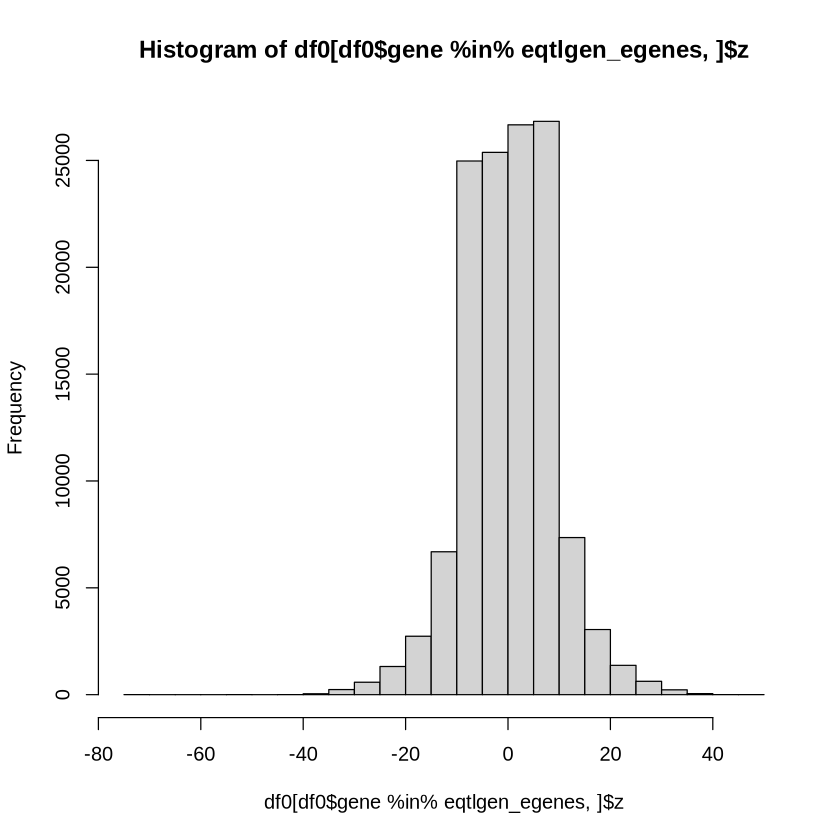

In [44]:
hist(df0[df0$gene %in% eqtlgen_egenes,]$z)

In [38]:
c(min(abs(df0[!(df0$gene %in% eqtlgen_egenes),]$z)),
max(abs(df0[!(df0$gene %in% eqtlgen_egenes),]$z)),
mean(abs(df0[!(df0$gene %in% eqtlgen_egenes),]$z)))

[1]  2.364964 38.821442  7.239826

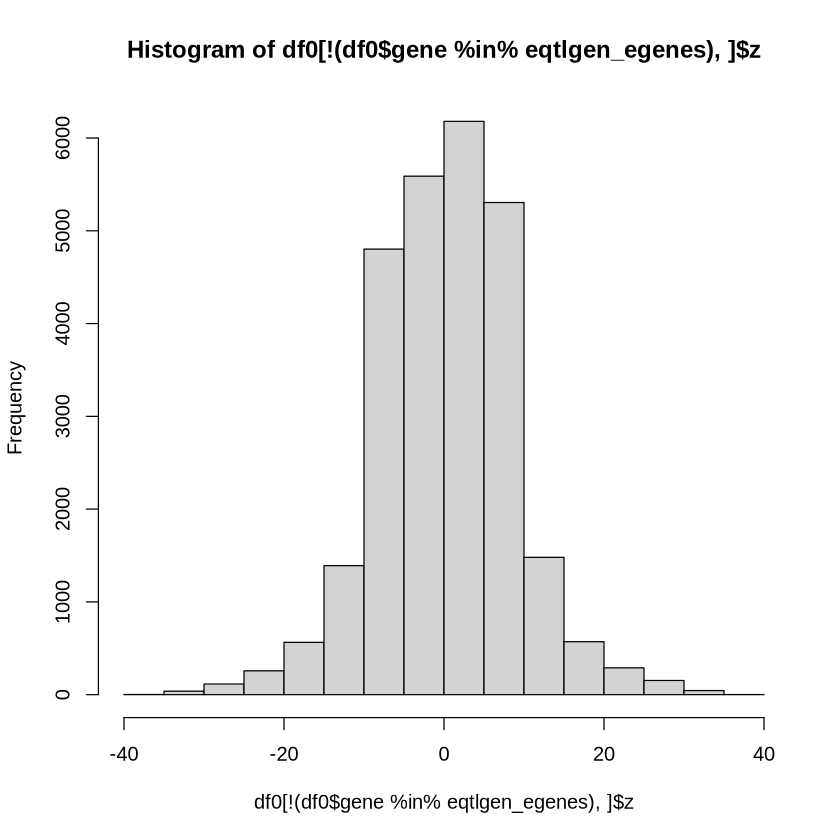

In [41]:
hist(df0[!(df0$gene %in% eqtlgen_egenes),]$z)

In [112]:
length(eqtlgen_egenes)

[1] 16987

In [113]:
length(tenk10k_egenes)

[1] 17674

In [15]:
tenk10k_egenes_unique = tenk10k_egenes[!(tenk10k_egenes %in% eqtlgen_egenes)]
length(tenk10k_egenes_unique)

[1] 4572

In [16]:
eqtlgen_egenes_unique = eqtlgen_egenes[!(eqtlgen_egenes %in% tenk10k_egenes)]
length(eqtlgen_egenes_unique)

[1] 3885

In [128]:
df_to_plot = data.frame(study=c('eQTLGen','TenK10K'),
                        n_egenes = c(length(eqtlgen_egenes), length(tenk10k_egenes)),
                       n_shared = c(length(eqtlgen_egenes)-length(eqtlgen_egenes_unique),
                                   length(tenk10k_egenes)-length(tenk10k_egenes_unique)))
df_to_plot

study,n_egenes,n_shared
<chr>,<int>,<int>
eQTLGen,16987,13102
TenK10K,17674,13102


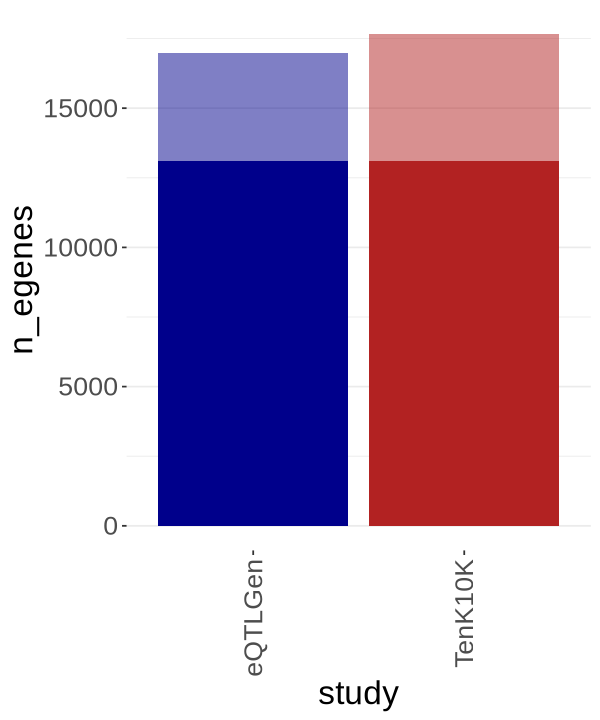

In [132]:
options(repr.plot.width = 5, repr.plot.height = 6) 
p = ggplot(df_to_plot, aes(x=study, y=n_egenes, fill=study)) 
p = p + geom_bar(stat = 'identity', aes(x=study, y=n_shared, fill=study))
p = p + geom_bar(stat = 'identity', alpha=0.5)
p = p + theme_bw() 
p = p + scale_fill_manual(values=c('darkblue','firebrick'))
p = p +
    theme( 
      panel.border = element_blank(),
      panel.grid.major.x = element_blank(),
      panel.grid.minor.x = element_blank(),
      text = element_text(size=20),
      axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1),
        legend.position='none'
    ) 
p

In [18]:
# shared
c(min(abs(combined[combined$Gene %in% tenk10k_egenes,]$Zscore)),
max(abs(combined[combined$Gene %in% tenk10k_egenes,]$Zscore)),
mean(abs(combined[combined$Gene %in% tenk10k_egenes,]$Zscore)))
# hist(eqtlgen_df2[eqtlgen_df2$Gene %in% tenk10k_egenes,]$Zscore)
c(min(abs(combined[combined$Gene %in% tenk10k_egenes,]$beta)),
max(abs(combined[combined$Gene %in% tenk10k_egenes,]$beta)),
mean(abs(combined[combined$Gene %in% tenk10k_egenes,]$beta)))

[1]   4.26260 200.75340  11.26008

[1] 0.03386606 2.74267248 0.17331939

In [19]:
# not found by us
c(min(abs(combined[!(combined$Gene %in% tenk10k_egenes),]$Zscore)),
max(abs(combined[!(combined$Gene %in% tenk10k_egenes),]$Zscore)),
mean(abs(combined[!(combined$Gene %in% tenk10k_egenes),]$Zscore)))
# hist(eqtlgen_df2[!(eqtlgen_df2$Gene %in% tenk10k_egenes),]$Zscore)
c(min(abs(combined[!(combined$Gene %in% tenk10k_egenes),]$beta)),
max(abs(combined[!(combined$Gene %in% tenk10k_egenes),]$beta)),
mean(abs(combined[!(combined$Gene %in% tenk10k_egenes),]$beta)))

[1]   4.26260 193.71980  10.47037

[1] 0.03386973 2.14550595 0.24468267

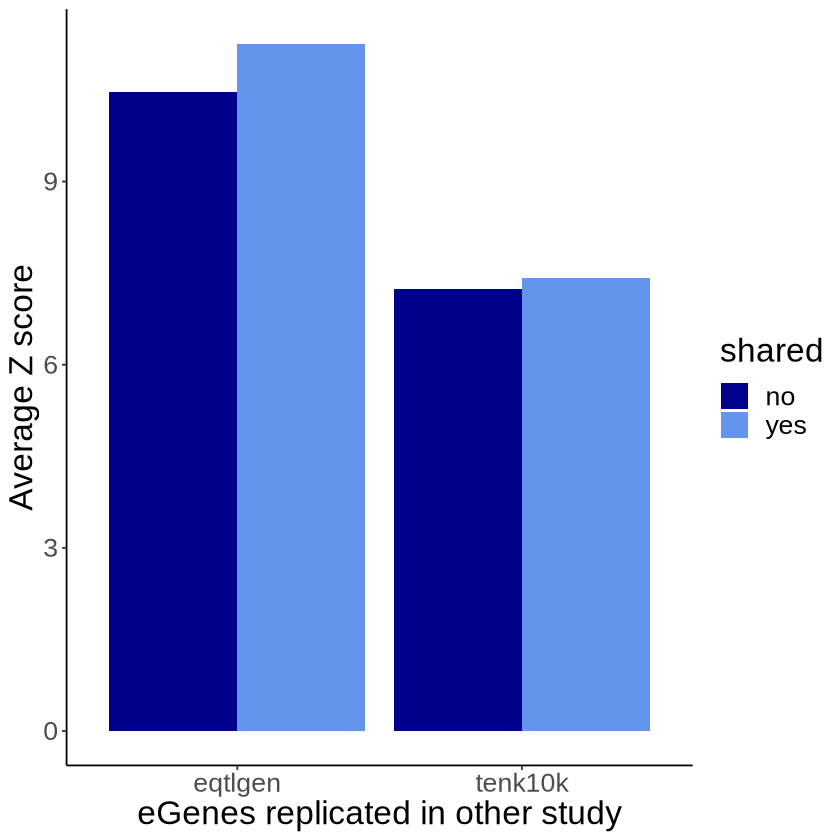

In [53]:
df_to_plot = data.frame(study = c('tenk10k','tenk10k','eqtlgen','eqtlgen'),
                       shared = c('yes','no','yes','no'),
                       average_z = c(7.41712448602113, 7.23982589474467, 11.2600844160189, 10.4703744917333))

p = ggplot(df_to_plot, aes(fill=shared, y=average_z, x=study)) 
p = p + scale_fill_manual(values=c('darkblue','cornflowerblue'))
p = p + geom_bar(position="dodge", stat="identity") 
p = p + theme_classic() + theme(text = element_text(size=20))
p + xlab('eGenes replicated in other study') + ylab('Average Z score')

In [12]:
mean(df_common_ct[df_common_ct$gene %in% tenk10k_egenes_unique,'n_celltypes_expressed'])
mean(df_common_ct[df_common_ct$gene %in% tenk10k_egenes_unique,'n_celltypes_egene'])

[1] 22.91989

[1] 11.6763

In [14]:
mean(df_common_ct[!(df_common_ct$gene %in% tenk10k_egenes_unique),'n_celltypes_expressed'])
mean(df_common_ct[!(df_common_ct$gene %in% tenk10k_egenes_unique),'n_celltypes_egene'])

[1] 26.22944

[1] 13.92177

In [26]:
celltypes = unique(df_common_ct$celltype)
celltypes

[1] "ASDC"              "B_intermediate"    "B_memory"         
 [4] "B_naive"           "CD14_Mono"         "CD16_Mono"        
 [7] "CD4_CTL"           "CD4_Naive"         "CD4_Proliferating"
[10] "CD4_TCM"           "CD4_TEM"           "CD8_Naive"        
[13] "CD8_Proliferating" "CD8_TCM"           "CD8_TEM"          
[16] "cDC1"              "cDC2"              "dnT"              
[19] "gdT"               "HSPC"              "ILC"              
[22] "MAIT"              "NK"                "NK_CD56bright"    
[25] "NK_Proliferating"  "pDC"               "Plasmablast"      
[28] "Treg"

In [51]:
rare_celltypes = c('ASDC','CD4_Proliferating','CD8_Proliferating','cDC1','cDC2','dnT','HSPC','ILC',
                   'NK_CD56bright','NK_Proliferating','pDC','Plasmablast')

In [52]:
df_egene_unique_genes = as.data.frame(df_common_ct)[,(colnames(df_common_ct) %in% c('gene',paste0(rare_celltypes,'_is_egene')))]
df_egene_unique_genes = df_egene_unique_genes[-which(duplicated(df_egene_unique_genes$gene)),]
rownames(df_egene_unique_genes) = df_egene_unique_genes$gene
df_egene_unique_genes$gene = c()
nrow(df_egene_unique_genes)
head(df_egene_unique_genes,2)

[1] 17674

,ASDC_is_egene,CD4_Proliferating_is_egene,CD8_Proliferating_is_egene,cDC1_is_egene,cDC2_is_egene,dnT_is_egene,HSPC_is_egene,ILC_is_egene,NK_CD56bright_is_egene,NK_Proliferating_is_egene,pDC_is_egene,Plasmablast_is_egene
,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>
ENSG00000020633,TRUE,TRUE,FALSE,FALSE,TRUE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,TRUE
ENSG00000049247,TRUE,TRUE,TRUE,FALSE,TRUE,TRUE,FALSE,TRUE,TRUE,TRUE,FALSE,FALSE


In [53]:
df_egene_unique_genes$n_rare_celltypes_egene = rowSums(df_egene_unique_genes)
df_egene_unique_genes$gene = rownames(df_egene_unique_genes)
nrow(df_egene_unique_genes)
table(df_egene_unique_genes$n_rare_celltypes_egene)

[1] 17674


   0    1    2    3    4    5    6    7    8    9   10   11   12 
7590 4955 2218 1148  658  349  231  160  137   64   60   51   53 

In [55]:
table(df_egene_unique_genes[df_egene_unique_genes$gene %in% tenk10k_egenes_unique,'n_rare_celltypes_egene'])
table(df_egene_unique_genes[!(df_egene_unique_genes$gene %in% tenk10k_egenes_unique),'n_rare_celltypes_egene'])


   0    1    2    3    4    5    6    7    8    9   10   11   12 
2258 1448  418  174   89   60   25   34   21   16    8    8   13 


   0    1    2    3    4    5    6    7    8    9   10   11   12 
5332 3507 1800  974  569  289  206  126  116   48   52   43   40 

In [62]:
sum(table(df_egene_unique_genes[df_egene_unique_genes$gene %in% tenk10k_egenes_unique,'n_rare_celltypes_egene']))

[1] 4572

In [58]:
1448/2314

[1] 0.6257563

In [61]:
sum(table(df_egene_unique_genes[!(df_egene_unique_genes$gene %in% tenk10k_egenes_unique),'n_rare_celltypes_egene']))

[1] 13102

In [60]:
3507/7770

[1] 0.4513514

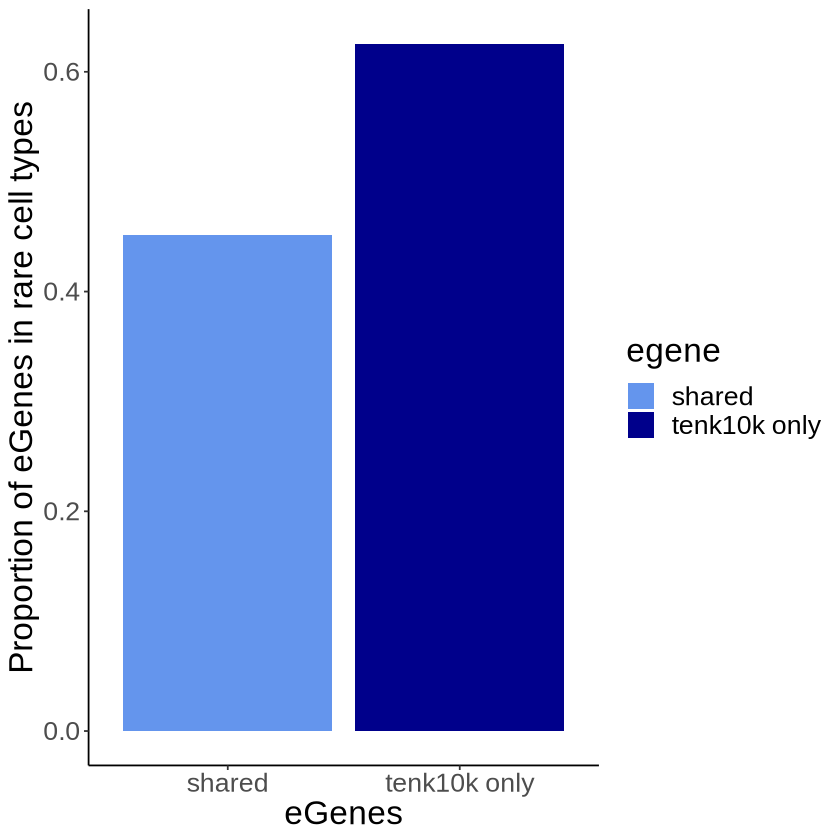

In [66]:
df_to_plot = data.frame(egene = c('tenk10k only','shared'),
                       prop_in_rare_cts = c(0.625756266205704, 0.451351351351351))

p = ggplot(df_to_plot, aes(fill=egene, y=prop_in_rare_cts, x=egene)) 
p = p + scale_fill_manual(values=c('cornflowerblue','darkblue'))
p = p + geom_bar(position="dodge", stat="identity") 
p = p + theme_classic() + theme(text = element_text(size=20))
p + xlab('eGenes') + ylab('Proportion of eGenes in rare cell types')

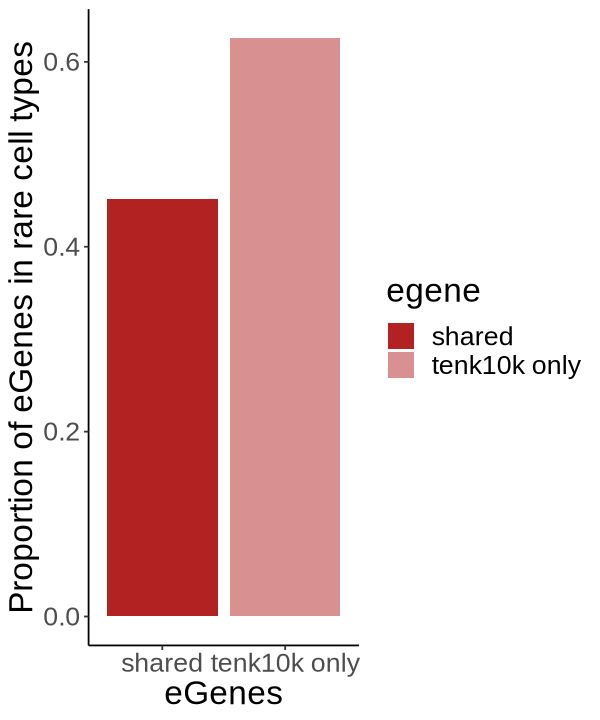

In [143]:
options(repr.plot.width = 5, repr.plot.height = 6)
df_to_plot = data.frame(egene = c('tenk10k only','shared'),
                       prop_in_rare_cts = c(0.625756266205704, 0.451351351351351))

p = ggplot(df_to_plot, aes(fill=egene, y=prop_in_rare_cts, x=egene)) 
p = p + scale_fill_manual(values=c('firebrick','#D99090'))
p = p + geom_bar(position="dodge", stat="identity") 
p = p + theme_classic() + theme(text = element_text(size=20))
p + xlab('eGenes') + ylab('Proportion of eGenes in rare cell types')

In [67]:
specific_file = '/directflow/SCCGGroupShare/projects/albhen/tenk10k-explore/results/tenk10k_phase1/common_eqtl_pairwise_scenario_table_v2_labelled.tsv'
df0 = read.csv(specific_file,sep='\t')
nrow(df0)
head(df0,2)

[1] 154932

,celltype,gene,MarkerID,n_expressed,n_egene,beta,se,pval,CD4_TCM,CD4_Naive,⋯,B_memory,Plasmablast,CD14_Mono,CD16_Mono,cDC2,pDC,cDC1,HSPC,ASDC,aggregated_score
,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,ASDC,ENSG00000020633,1:24970252:A:C,28,14,-0.213571,0.0492147,1.42751e-05,3,3,⋯,2,3,3,2,3,2,2,2,NA,3
2,ASDC,ENSG00000049247,1:7913587:T:TTTTTTGTTGTTGTTG,14,14,6.878290,0.8824930,6.48378e-15,1,1,⋯,1,1,1,1,3,1,1,1,NA,4


In [93]:
df1 = df0[,c('gene','n_expressed','n_egene','aggregated_score')]
df1 = df1[-which(duplicated(df1$gene)),]
nrow(df1)

[1] 17674

In [94]:
mean(df1[df1$gene %in% tenk10k_egenes_unique,'n_expressed'])
mean(df1[!(df1$gene %in% tenk10k_egenes_unique),'n_expressed'])

[1] 16.70888

[1] 23.6167

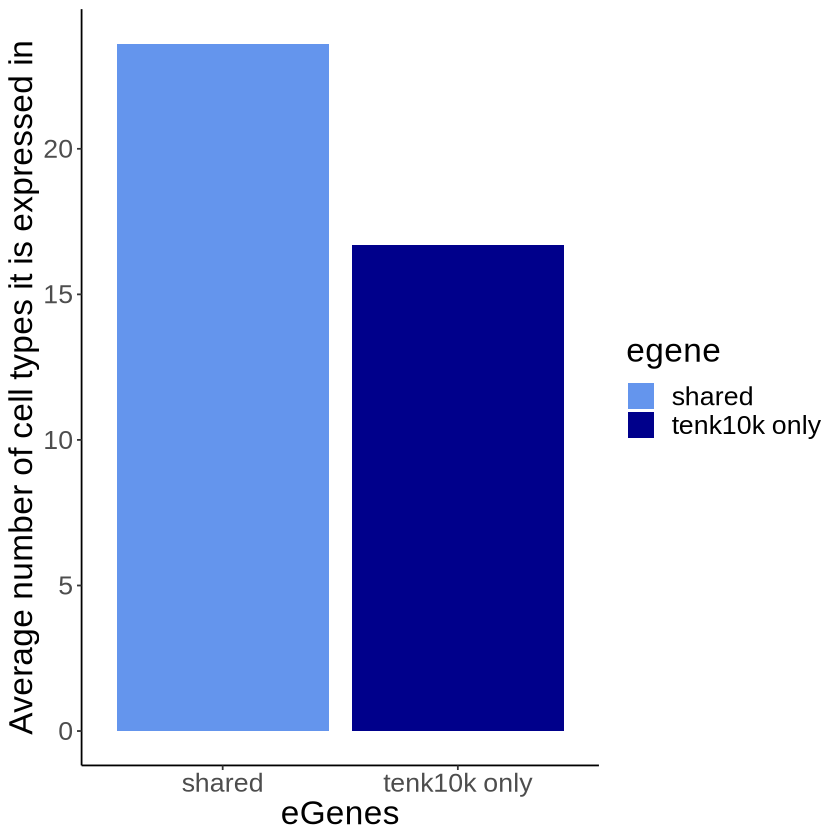

In [109]:
df_to_plot = data.frame(egene = c('tenk10k only','shared'),
                       avg_n_expressed = c(16.7088801399825, 23.6166997404976))
p = ggplot(df_to_plot, aes(fill=egene, y=avg_n_expressed, x=egene)) 
p = p + scale_fill_manual(values=c('cornflowerblue','darkblue'))
p = p + geom_bar(position="dodge", stat="identity") 
p = p + theme_classic() + theme(text = element_text(size=20))
p + xlab('eGenes') + ylab('Average number of cell types it is expressed in')

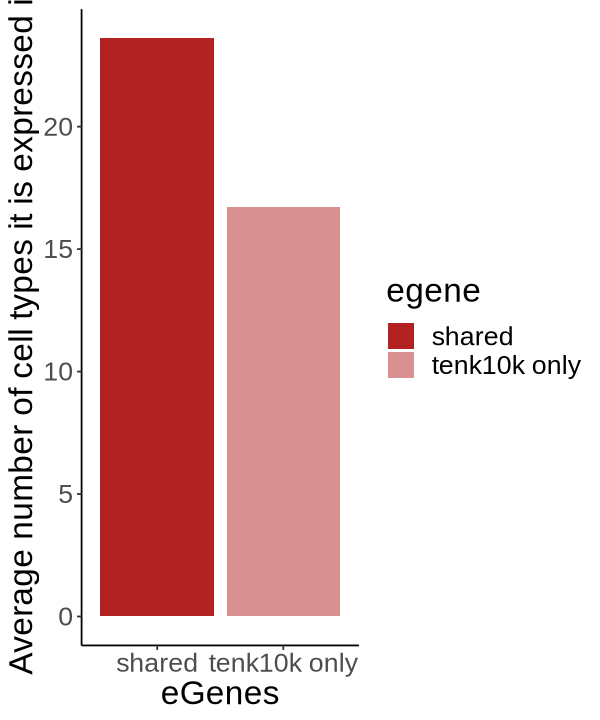

In [142]:
options(repr.plot.width = 5, repr.plot.height = 6)
df_to_plot = data.frame(egene = c('tenk10k only','shared'),
                       avg_n_expressed = c(16.7088801399825, 23.6166997404976))
p = ggplot(df_to_plot, aes(fill=egene, y=avg_n_expressed, x=egene)) 
p = p + scale_fill_manual(values=c('firebrick','#D99090'))
p = p + geom_bar(position="dodge", stat="identity") 
p = p + theme_classic() + theme(text = element_text(size=20))
p + xlab('eGenes') + ylab('Average number of cell types it is expressed in')

In [95]:
mean(df1[df1$gene %in% tenk10k_egenes_unique,'n_egene'])
mean(df1[!(df1$gene %in% tenk10k_egenes_unique),'n_egene'])

[1] 5.858924

[1] 9.780568

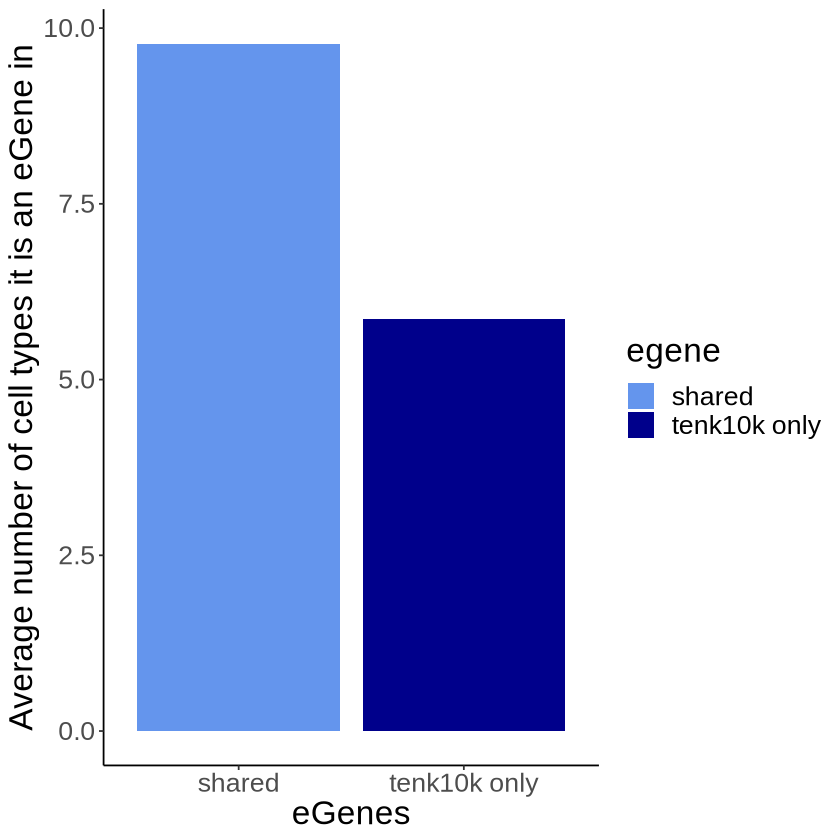

In [110]:
df_to_plot = data.frame(egene = c('tenk10k only','shared'),
                       avg_n_egene = c(5.85892388451444, 9.7805678522363))
p = ggplot(df_to_plot, aes(fill=egene, y=avg_n_egene, x=egene)) 
p = p + scale_fill_manual(values=c('cornflowerblue','darkblue'))
p = p + geom_bar(position="dodge", stat="identity") 
p = p + theme_classic() + theme(text = element_text(size=20))
p + xlab('eGenes') + ylab('Average number of cell types it is an eGene in')

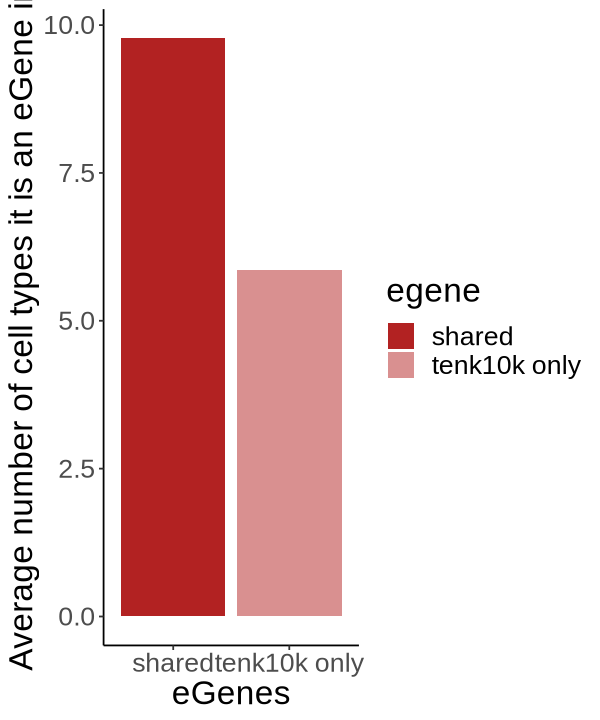

In [140]:
options(repr.plot.width = 5, repr.plot.height = 6)
df_to_plot = data.frame(egene = c('tenk10k only','shared'),
                       avg_n_egene = c(5.85892388451444, 9.7805678522363))
p = ggplot(df_to_plot, aes(fill=egene, y=avg_n_egene, x=egene)) 
p = p + scale_fill_manual(values=c('firebrick','#D99090'))
p = p + geom_bar(position="dodge", stat="identity") 
p = p + theme_classic() + theme(text = element_text(size=20))
p + xlab('eGenes') + ylab('Average number of cell types it is an eGene in')

In [97]:
mean(df1[df1$gene %in% tenk10k_egenes_unique,'aggregated_score'])
mean(df1[!(df1$gene %in% tenk10k_egenes_unique),'aggregated_score'])

[1] 3.022091

[1] 3.433598

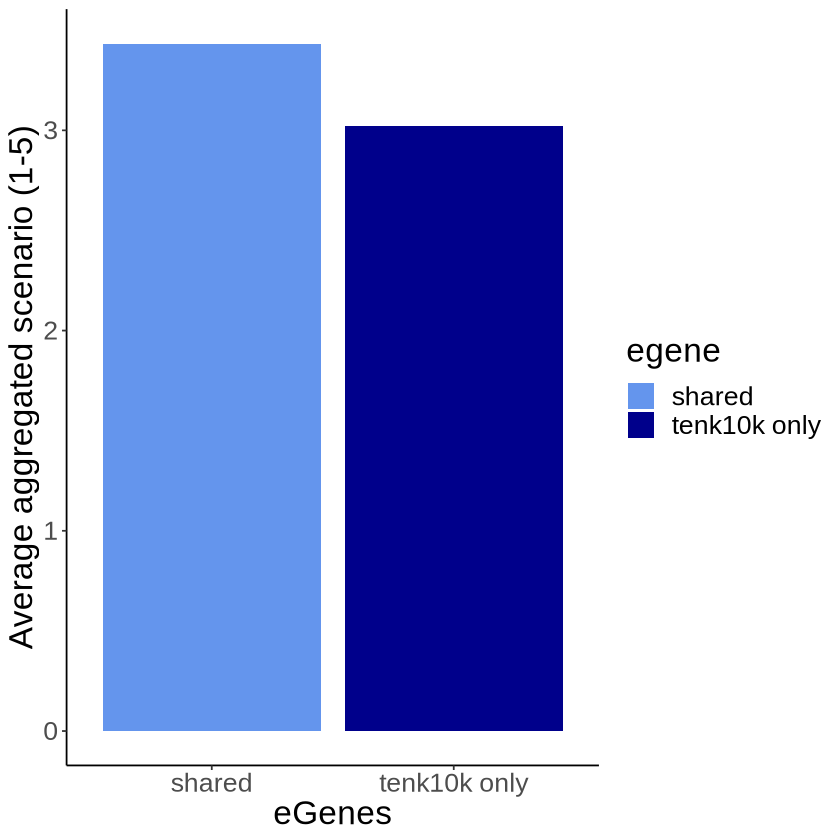

In [111]:
df_to_plot = data.frame(egene = c('tenk10k only','shared'),
                       avg_scenario = c(3.02209098862642, 3.43359792398107))
p = ggplot(df_to_plot, aes(fill=egene, y=avg_scenario, x=egene)) 
p = p + scale_fill_manual(values=c('cornflowerblue','darkblue'))
p = p + geom_bar(position="dodge", stat="identity") 
p = p + theme_classic() + theme(text = element_text(size=20))
p + xlab('eGenes') + ylab('Average aggregated scenario (1-5)')

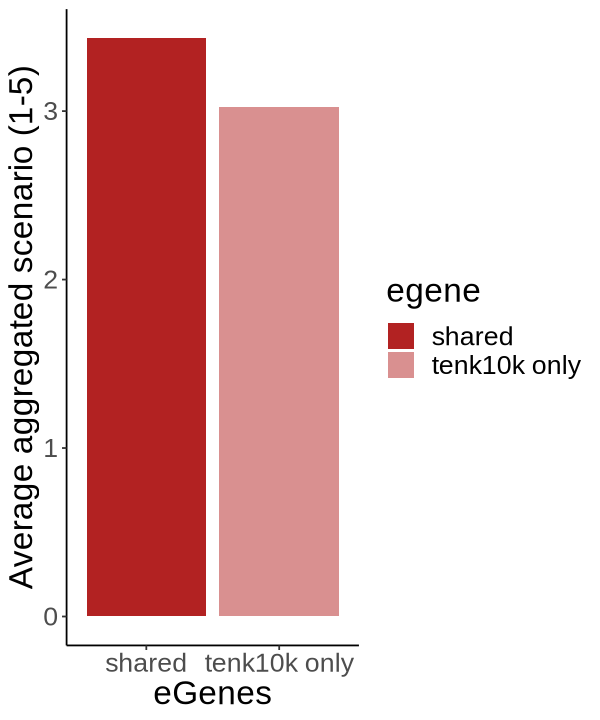

In [139]:
options(repr.plot.width = 5, repr.plot.height = 6)
df_to_plot = data.frame(egene = c('tenk10k only','shared'),
                       avg_scenario = c(3.02209098862642, 3.43359792398107))
p = ggplot(df_to_plot, aes(fill=egene, y=avg_scenario, x=egene)) 
p = p + scale_fill_manual(values=c('firebrick','#D99090'))
p = p + geom_bar(position="dodge", stat="identity") 
p = p + theme_classic() + theme(text = element_text(size=20))
p + xlab('eGenes') + ylab('Average aggregated scenario (1-5)')

In [96]:
table(df1[df1$gene %in% tenk10k_egenes_unique,'aggregated_score'])
table(df1[!(df1$gene %in% tenk10k_egenes_unique),'aggregated_score'])


   1    2    3    4    5 
 276  926 1906 1349  115 


   1    2    3    4    5 
 143  807 5972 5586  594 

In [98]:
sum(c(276,926))/sum(c(276,926,1906,1349,115))
sum(c(143,807))/sum(c(143,807,5972,5586,594))

[1] 0.2629046

[1] 0.07250801

In [107]:
0.0725080140436575/0.262904636920385

[1] 0.2757959

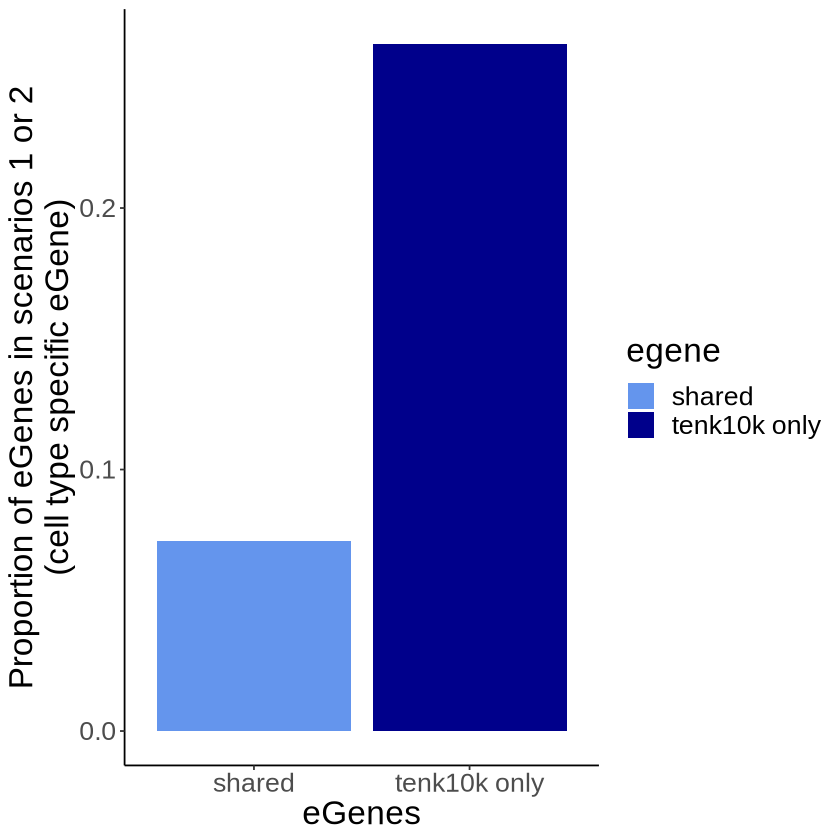

In [100]:
df_to_plot = data.frame(egene = c('tenk10k only','shared'),
                       prop_in_scenarios1_2 = c(0.262904636920385, 0.0725080140436575))
p = ggplot(df_to_plot, aes(fill=egene, y=prop_in_scenarios1_2, x=egene)) 
p = p + scale_fill_manual(values=c('cornflowerblue','darkblue'))
p = p + geom_bar(position="dodge", stat="identity") 
p = p + theme_classic() + theme(text = element_text(size=20))
p + xlab('eGenes') + ylab('Proportion of eGenes in scenarios 1 or 2\n(cell type specific eGene)')

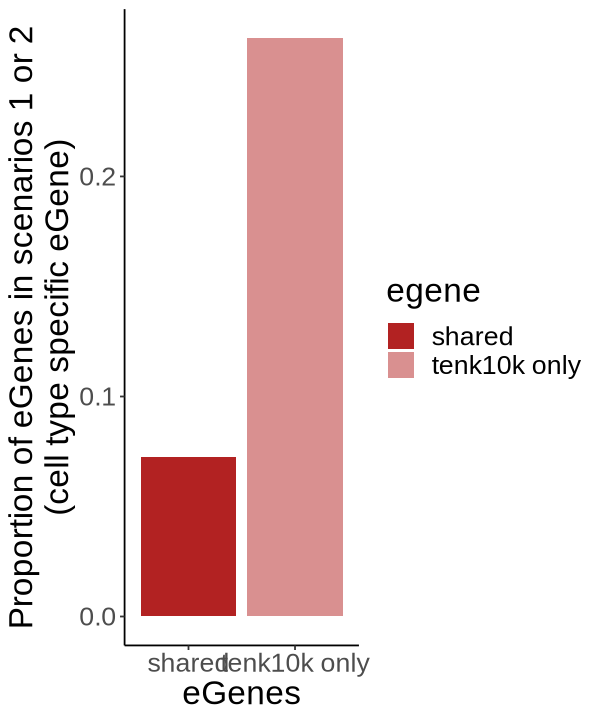

In [141]:
options(repr.plot.width = 5, repr.plot.height = 6) 
df_to_plot = data.frame(egene = c('tenk10k only','shared'),
                       prop_in_scenarios1_2 = c(0.262904636920385, 0.0725080140436575))
p = ggplot(df_to_plot, aes(fill=egene, y=prop_in_scenarios1_2, x=egene)) 
p = p + scale_fill_manual(values=c('firebrick','#D99090'))
p = p + geom_bar(position="dodge", stat="identity") 
p = p + theme_classic() + theme(text = element_text(size=20))
p + xlab('eGenes') + ylab('Proportion of eGenes in scenarios 1 or 2\n(cell type specific eGene)')

In [102]:
sum(c(276))/sum(c(276,926,1906,1349,115))
sum(c(143))/sum(c(143,807,5972,5586,594))

[1] 0.06036745

[1] 0.01091436

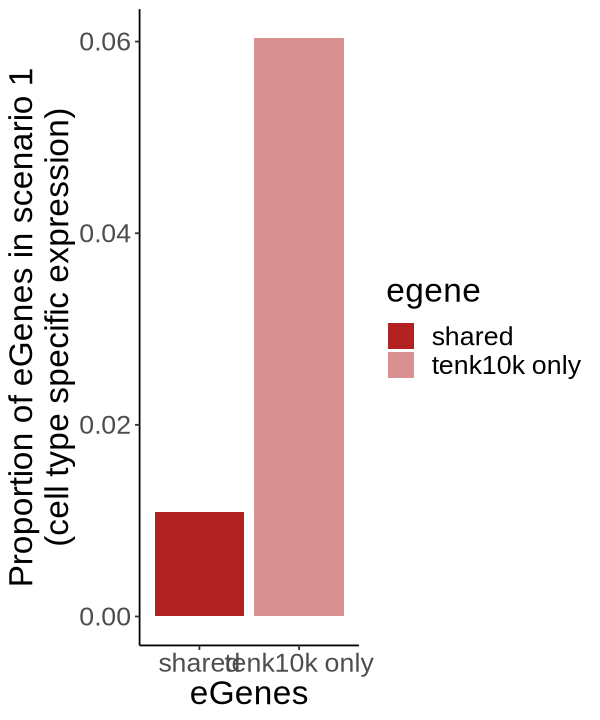

In [138]:
options(repr.plot.width = 5, repr.plot.height = 6) 
df_to_plot = data.frame(egene = c('tenk10k only','shared'),
                       prop_in_scenarios1 = c(0.0603674540682415, 0.0109143642192032))
p = ggplot(df_to_plot, aes(fill=egene, y=prop_in_scenarios1, x=egene)) 
p = p + scale_fill_manual(values=c('firebrick','#D99090'))
p = p + geom_bar(position="dodge", stat="identity") 
p = p + theme_classic() + theme(text = element_text(size=20))
p + xlab('eGenes') + ylab('Proportion of eGenes in scenario 1\n(cell type specific expression)')

In [104]:
sum(c(926))/sum(c(276,926,1906,1349,115))
sum(c(807))/sum(c(143,807,5972,5586,594))

[1] 0.2025372

[1] 0.06159365

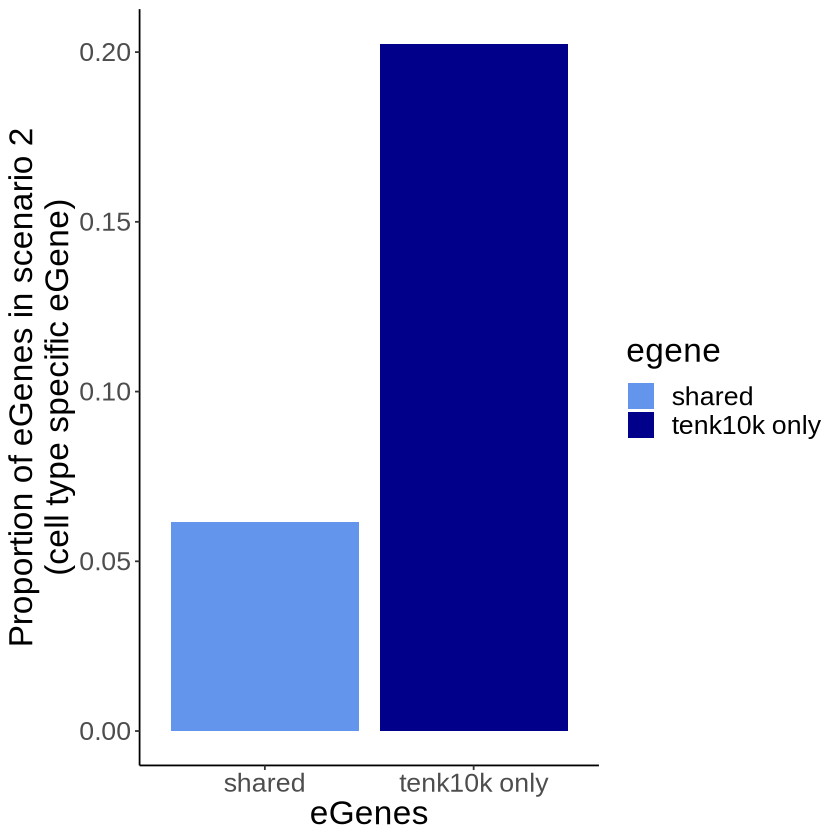

In [105]:
df_to_plot = data.frame(egene = c('tenk10k only','shared'),
                       prop_in_scenarios2 = c(0.202537182852143, 0.0615936498244543))
p = ggplot(df_to_plot, aes(fill=egene, y=prop_in_scenarios2, x=egene)) 
p = p + scale_fill_manual(values=c('cornflowerblue','darkblue'))
p = p + geom_bar(position="dodge", stat="identity") 
p = p + theme_classic() + theme(text = element_text(size=20))
p + xlab('eGenes') + ylab('Proportion of eGenes in scenario 2\n(cell type specific eGene)')

In [56]:
mydir = '/directflow/SCCGGroupShare/projects/anncuo/TenK10K_pilot/tenk10k/review_files/ct_mean_expression_files/'
df_all = read.csv(paste0(mydir,'mean_expression_all_genes_all_celltypes.csv'), row.names = 1)

In [57]:
dim(df_all)
head(df_all,2)

[1] 37178    30

,gene,chrom,mean_ASDC,mean_B_intermediate,mean_B_memory,mean_B_naive,mean_CD14_Mono,mean_CD16_Mono,mean_CD4_CTL,mean_CD4_Naive,⋯,mean_gdT,mean_HSPC,mean_ILC,mean_MAIT,mean_NK,mean_NK_CD56bright,mean_NK_Proliferating,mean_pDC,mean_Plasmablast,mean_Treg
,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2,ENSG00000000419,20,1.0882353,0.43761037,0.4225268,0.35185948,0.5324157,0.5811292,0.35086813,0.3855598,⋯,0.3944346,0.9328859,0.3084990,0.3769801,0.35631074,0.3969260,0.6485504,0.7954968,1.1469380,0.3598688
3,ENSG00000000457,1,0.1941176,0.08857861,0.1054823,0.08342382,0.1218999,0.1714356,0.09576565,0.1009841,⋯,0.1049358,0.2601342,0.1605855,0.1041616,0.08793871,0.1539688,0.1495168,0.4966949,0.2637029,0.1081986


In [58]:
df_all$mean_overall = rowMeans(df_all[,3:20])

In [61]:
mean(df_all[df_all$gene %in% eqtlgen_egenes_unique,'mean_overall'])
mean(df_all[df_all$gene %in% tenk10k_egenes_unique,'mean_overall'])
mean(df_all[!(df_all$gene %in% c(eqtlgen_egenes_unique,tenk10k_egenes_unique)),'mean_overall'])

[1] 0.04370835

[1] 0.275884

[1] 0.2962584

In [60]:
mean(df_all[df_all$gene %in% eqtlgen_egenes_unique,'mean_overall'])
mean(df_all[!(df_all$gene %in% eqtlgen_egenes_unique),'mean_overall'])

[1] 0.04370835

[1] 0.2936057

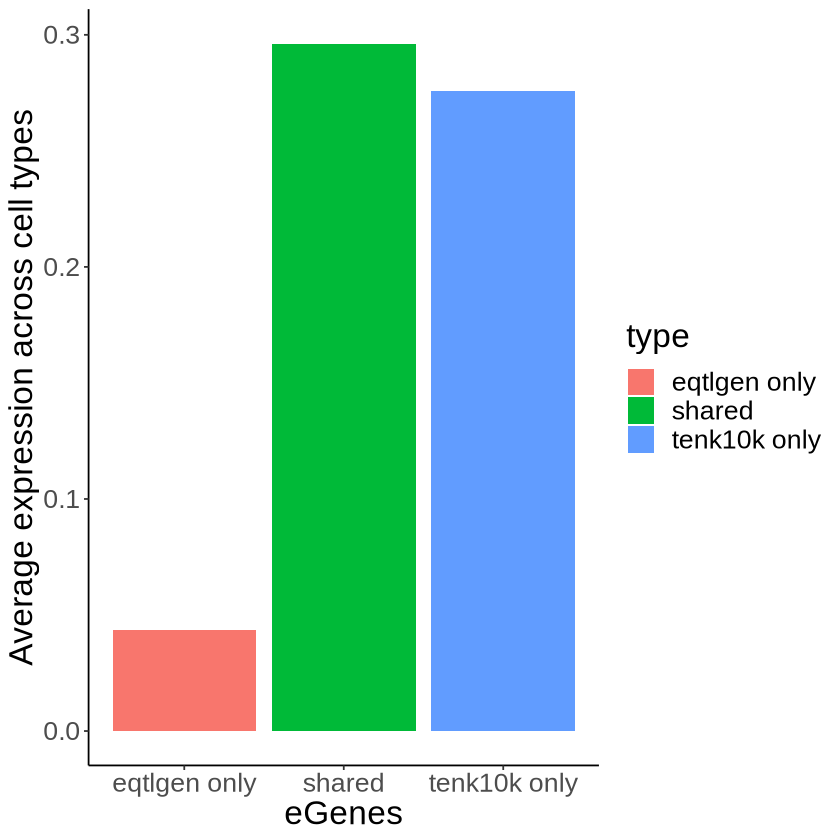

In [63]:
df_to_plot = data.frame(type = c('eqtlgen only','tenk10k only','shared'),
                       mean_overall = c(0.043708346812915, 0.275883989461892, 0.296258442324378))

p = ggplot(df_to_plot, aes(fill=type, y=mean_overall, x=type)) 
# p = p + scale_fill_manual(values=c('darkblue','cornflowerblue'))
p = p + geom_bar(stat="identity") 
p = p + theme_classic() + theme(text = element_text(size=20))
p + xlab('eGenes') + ylab('Average expression across cell types')

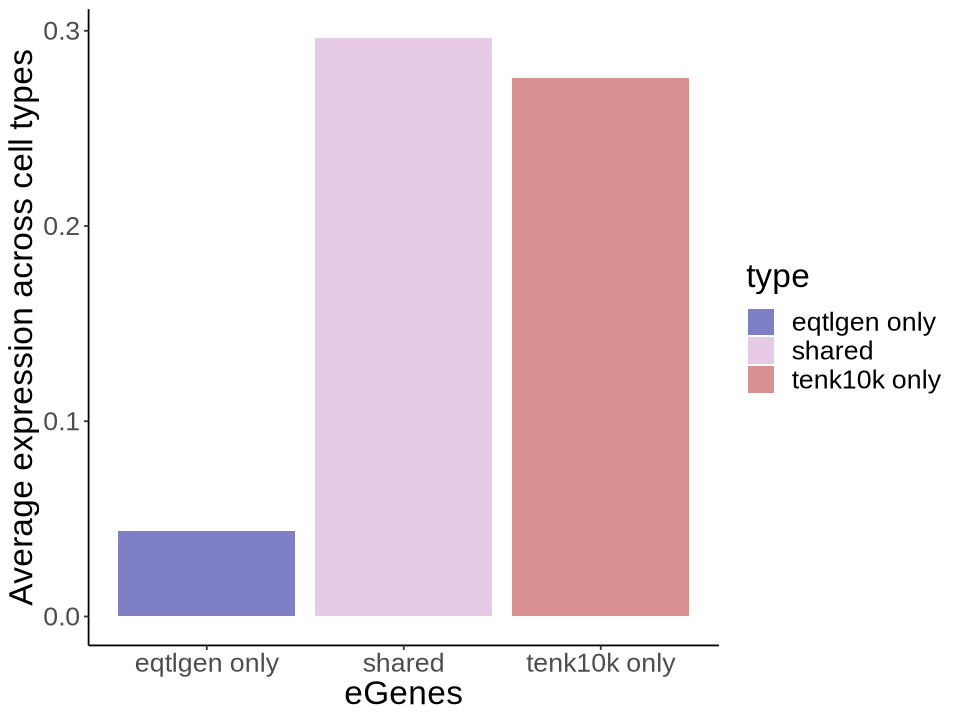

In [134]:
options(repr.plot.width = 8, repr.plot.height = 6) 
df_to_plot = data.frame(type = c('eqtlgen only','tenk10k only','shared'),
                       mean_overall = c(0.043708346812915, 0.275883989461892, 0.296258442324378))

p = ggplot(df_to_plot, aes(fill=type, y=mean_overall, x=type)) 
p = p + geom_bar(stat="identity", alpha=0.5) 
p = p + theme_classic() + theme(text = element_text(size=20))
p = p + scale_fill_manual(values=c('darkblue','plum3','firebrick'))
p + xlab('eGenes') + ylab('Average expression across cell types')

In [17]:
adata_var = as.data.frame(fread('/directflow/SCCGGroupShare/projects/anncuo/300libraries_n1925_adata_raw_var.csv'))
nrow(adata_var)
head(adata_var,2)

[1] 36842

,V1,gene_ids,feature_types,genome,mt,ribo,hb,chr,source,type,⋯,phase,attributes,gene_id,gene_name,gene_type,n_counts,highly_variable,means,dispersions,dispersions_norm
,<chr>,<chr>,<chr>,<chr>,<lgl>,<lgl>,<lgl>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>
1,ENSG00000290825,ENSG00000290825,Gene Expression,GRCh38,FALSE,FALSE,FALSE,chr1,HAVANA,gene,⋯,.,"gene_id """"ENSG00000290825.1""""; gene_type """"lncRNA""""; gene_name """"DDX11L2""""; level 2; tag """"overlaps_pseudogene"""";",ENSG00000290825.1,DDX11L2,lncRNA,213,FALSE,5.110075e-05,0.5333406,-0.26852970
2,ENSG00000243485,ENSG00000243485,Gene Expression,GRCh38,FALSE,FALSE,FALSE,chr1,HAVANA,gene,⋯,.,"gene_id """"ENSG00000243485.5""""; gene_type """"lncRNA""""; gene_name """"MIR1302-2HG""""; level 2; hgnc_id """"HGNC:52482""""; tag """"ncRNA_host""""; havana_gene """"OTTHUMG00000000959.2"""";",ENSG00000243485.5,MIR1302-2HG,lncRNA,109,FALSE,2.709609e-05,0.5989793,-0.05224023


In [24]:
df0 = adata_var %>% mutate(genelist = ifelse(gene_ids %in% eqtlgen_egenes_unique, "unique-to-eqtlgen","not-unique-to-eqtlgen"))
df01 = df0 %>% group_by(genelist) %>% summarise(mean_expr = mean(means))
df01

genelist,mean_expr
<chr>,<dbl>
not-unique-to-eqtlgen,0.13157535
unique-to-eqtlgen,0.01807888


In [25]:
df1 = adata_var %>% mutate(genelist = ifelse(gene_ids %in% tenk10k_egenes_unique, "unique-to-tenk10k","not-unique-to-tenk10k"))
df11 = df1 %>% group_by(genelist) %>% summarise(mean_expr = mean(means))
df11

genelist,mean_expr
<chr>,<dbl>
not-unique-to-tenk10k,0.12997883
unique-to-tenk10k,0.09237614
